/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


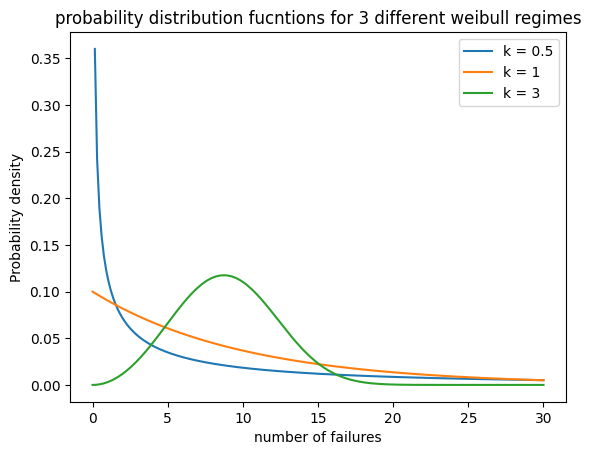

In [1]:
from scipy.stats import weibull_min
import numpy as np
import matplotlib.pyplot as plt

#Looking at theoretical difference weibull regimes

parameters = [0.5,1,3]    # shape parameters
scale = 10     # scale parameter (lambda)
x = np.linspace(0,30,200)
for k in parameters:
  y = weibull_min.pdf(x,k,scale=scale)
  plt.plot(x,y,label = f'k = {k}')
plt.title('probability distribution fucntions for 3 different weibull regimes')
plt.xlabel('time')
plt.ylabel('Probability density')
plt.legend()
plt.show()


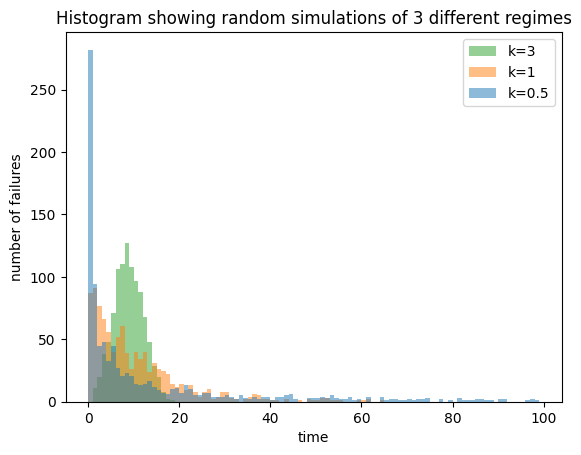

In [2]:
#Histogram showing simulations of 3 different regimes
parameters = [0.5,1,3]    # shape parameters
scale = 10     # scale parameter (lambda)

all_data = []
labels = []
bins = np.arange(0,100,1)


for k in parameters:
  y = weibull_min.rvs(k,scale=scale,size = 1000)
  all_data.append(y)
  labels.append(f'k={k}')
plt.hist(all_data,label = labels,bins = bins,histtype = 'stepfilled',alpha = 0.5)
plt.xlabel('time')
plt.ylabel('number of failures')
plt.title('Histogram showing random simulations of 3 different regimes')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


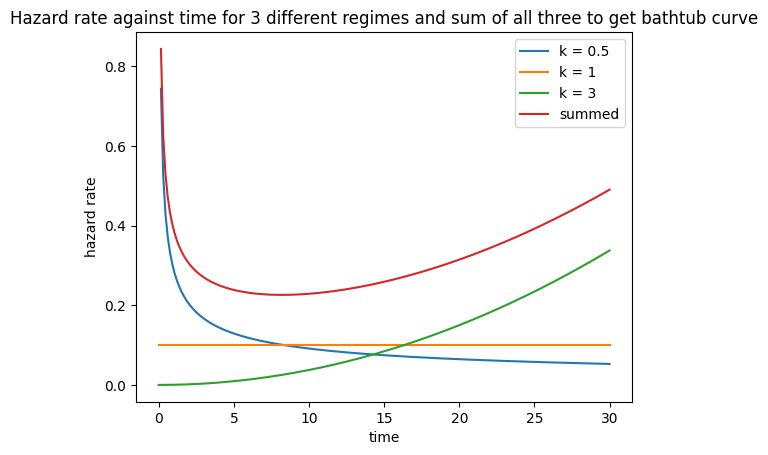

In [3]:
parameters_scales = [[0.5,3],[1,10],[3,20]]    # shape parameters
x = np.linspace(0,30,200)
summed_hazard_rate = np.zeros(200)

for k,scale in parameters_scales:
  y = weibull_min.pdf(x,k,scale=scale)
  surviving = 1-weibull_min.cdf(x,k,scale=scale)
  hazard_rate = y/surviving
  plt.plot(x,hazard_rate,label = f'k = {k}')
  summed_hazard_rate += hazard_rate
plt.plot(x,summed_hazard_rate,label = 'summed')
plt.xlabel('time')
plt.ylabel('hazard rate')
plt.title('Hazard rate against time for 3 different regimes and sum of all three to get bathtub curve')
plt.legend()
plt.show()